# Advanced Machine Learning - Week 1 Lab
## Foundations: Optimization Algorithms with TensorFlow/Keras

**Learning Objectives:**
1. Implement and compare SGD, Momentum, and Adam using TensorFlow/Keras
2. Train an MLP on MNIST dataset
3. Analyze convergence behavior and generalization
4. Establish TensorFlow baseline for the module

**Duration:** 2 hours

**Structure:**
- Part 1: Setup & Dataset Loading
- Part 2: Model Architecture
- Part 3: Optimizer Comparison Experiments
- Part 4: Results Visualization
- Part 5: Critical Analysis
- Part 6: Advanced Extensions

---

## Part 1: Setup & Imports

Install required packages (if needed on Colab):

In [ ]:
# Uncomment if running on Google Colab
# !pip install -q tensorflow scikit-learn seaborn

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses, metrics

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU available:", tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n✅ All imports successful!")

2026-02-20 02:19:23.721171: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-20 02:19:23.736414: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 02:19:24.336377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 02:19:28.059405: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

✅ TensorFlow version: 2.20.0
✅ GPU available: []

✅ All imports successful!


2026-02-20 02:19:28.783261: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


---
## Part 2: Dataset Loading & Preprocessing

**MNIST Dataset:**
- 60,000 training images (28×28 grayscale)
- 10,000 test images
- 10 classes (digits 0-9)

We will:
1. Load the dataset from `tf.keras.datasets`
2. Flatten images to vectors (784 features)
3. Normalize pixel values to [0, 1]
4. Optionally subsample for faster training

In [3]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Original shapes:")
print(f"  Train: X={x_train.shape}, y={y_train.shape}")
print(f"  Test:  X={x_test.shape}, y={y_test.shape}")

# Flatten images: (28, 28) -> (784,)
x_train_flat = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test_flat = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0

print(f"\nAfter flattening and normalization:")
print(f"  Train: {x_train_flat.shape}")
print(f"  Test:  {x_test_flat.shape}")
print(f"  Value range: [{x_train_flat.min():.2f}, {x_train_flat.max():.2f}]")

Loading MNIST dataset...
Original shapes:
  Train: X=(60000, 28, 28), y=(60000,)
  Test:  X=(10000, 28, 28), y=(10000,)

After flattening and normalization:
  Train: (60000, 784)
  Test:  (10000, 784)
  Value range: [0.00, 1.00]


In [4]:
# Optional: Use subset for faster training (adjust based on your resources)
USE_SUBSET = True  # Set to False to use full dataset
SUBSET_SIZE = 20000

if USE_SUBSET:
    x_train_flat = x_train_flat[:SUBSET_SIZE]
    y_train = y_train[:SUBSET_SIZE]
    print(f"\n⚡ Using subset: {SUBSET_SIZE} training samples")
else:
    print(f"\n📊 Using full dataset: {len(x_train_flat)} training samples")

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nClass distribution: {dict(zip(unique, counts))}")


⚡ Using subset: 20000 training samples

Class distribution: {np.uint8(0): np.int64(1994), np.uint8(1): np.int64(2281), np.uint8(2): np.int64(1929), np.uint8(3): np.int64(2076), np.uint8(4): np.int64(1945), np.uint8(5): np.int64(1775), np.uint8(6): np.int64(1971), np.uint8(7): np.int64(2093), np.uint8(8): np.int64(1922), np.uint8(9): np.int64(2014)}


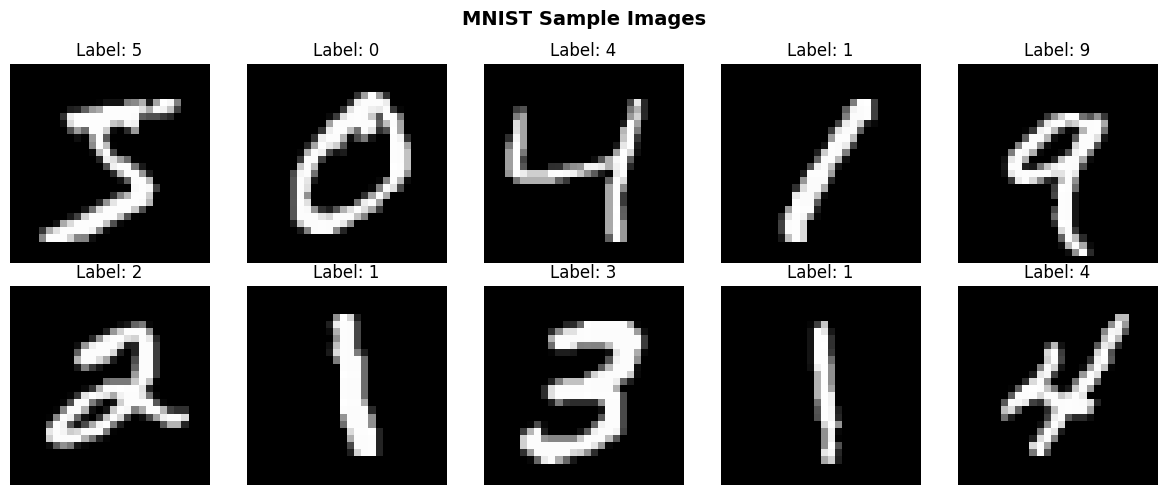

In [5]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("MNIST Sample Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Neural Network Architecture

**Model Architecture:**
```
Input Layer:     784 neurons (28×28 pixels)
                   ↓
Hidden Layer:    128 neurons + ReLU activation
                   ↓
Output Layer:    10 neurons + Softmax (class probabilities)
```

**Loss Function:** Sparse Categorical Cross-Entropy

**Initialization:** He Normal (recommended for ReLU)

In [6]:
def build_mlp_model(input_dim=784, hidden_dim=128, output_dim=10):
    """
    Build a simple 2-layer MLP for MNIST classification.
    
    Args:
        input_dim: Number of input features (784 for flattened MNIST)
        hidden_dim: Number of hidden layer neurons
        output_dim: Number of output classes (10 for MNIST)
    
    Returns:
        model: Uncompiled Keras Sequential model
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(
            hidden_dim, 
            activation='relu',
            kernel_initializer='he_normal',
            name='hidden_layer'
        ),
        layers.Dense(
            output_dim, 
            activation='softmax',
            name='output_layer'
        )
    ], name='MLP_MNIST')
    
    return model

# Create and display model architecture
sample_model = build_mlp_model()
sample_model.summary()

print("\n✅ Model architecture defined")

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model architecture defined


---
## Part 4: Training Function with Different Optimizers

We will compare three optimizers:

1. **SGD (Stochastic Gradient Descent)**
   - Vanilla gradient descent
   - Update: $w_{t+1} = w_t - \eta \nabla L(w_t)$

2. **SGD with Momentum**
   - Accelerates convergence in consistent directions
   - $v_{t+1} = \beta v_t + \nabla L(w_t)$
   - $w_{t+1} = w_t - \eta v_{t+1}$

3. **Adam (Adaptive Moment Estimation)**
   - Adapts learning rate per parameter
   - Combines momentum and RMSprop
   - Most popular for deep learning

In [7]:
def train_with_optimizer(optimizer_name, learning_rate, 
                         x_train, y_train, x_test, y_test,
                         epochs=25, batch_size=64, verbose=True):
    """
    Train MLP model with specified optimizer.
    
    Args:
        optimizer_name: str, one of ['sgd', 'momentum', 'adam']
        learning_rate: float
        x_train, y_train: Training data
        x_test, y_test: Test data
        epochs: Number of training epochs
        batch_size: Mini-batch size
        verbose: Print training progress
    
    Returns:
        history: Training history
        test_acc: Final test accuracy
        model: Trained model
    """
    # Build fresh model
    model = build_mlp_model()
    
    # Select optimizer
    if optimizer_name == 'sgd':
        optimizer = optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'momentum':
        optimizer = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'adam':
        optimizer = optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    
    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[metrics.SparseCategoricalAccuracy(name='accuracy')]
    )
    
    # Print header
    print("\n" + "="*70)
    print(f"Training with {optimizer_name.upper()} | Learning Rate = {learning_rate}")
    print("="*70)
    
    # Train model
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(x_test, y_test),
        verbose=2 if verbose else 0
    )
    
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    print(f"\n✅ Final Test Accuracy ({optimizer_name.upper()}): {test_acc:.4f}")
    print(f"✅ Final Test Loss ({optimizer_name.upper()}): {test_loss:.4f}")
    
    return history, test_acc, model

print("✅ Training function defined")

✅ Training function defined


---
## Part 5: Optimizer Comparison Experiments

Now we train the same architecture with three different optimizers:
- **SGD** with learning rate 0.01
- **Momentum** (SGD + momentum=0.9) with learning rate 0.01
- **Adam** with learning rate 0.001 (typically uses smaller LR)

⏱️ **Note:** Training will take a few minutes per optimizer.

In [8]:
# Configuration
EPOCHS = 25
BATCH_SIZE = 64

# Dictionary to store results
results = {}

print("Starting optimizer comparison experiments...")
print(f"Configuration: {EPOCHS} epochs, batch size {BATCH_SIZE}")

Starting optimizer comparison experiments...
Configuration: 25 epochs, batch size 64


In [9]:
# Experiment 1: SGD
hist_sgd, acc_sgd, model_sgd = train_with_optimizer(
    optimizer_name='sgd',
    learning_rate=0.01,
    x_train=x_train_flat,
    y_train=y_train,
    x_test=x_test_flat,
    y_test=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

results['SGD'] = {
    'history': hist_sgd,
    'test_acc': acc_sgd,
    'model': model_sgd
}


Training with SGD | Learning Rate = 0.01
Epoch 1/25
313/313 - 4s - 13ms/step - accuracy: 0.6507 - loss: 1.4174 - val_accuracy: 0.8257 - val_loss: 0.8421
Epoch 2/25
313/313 - 2s - 7ms/step - accuracy: 0.8456 - loss: 0.6904 - val_accuracy: 0.8716 - val_loss: 0.5571
Epoch 3/25
313/313 - 4s - 11ms/step - accuracy: 0.8721 - loss: 0.5191 - val_accuracy: 0.8876 - val_loss: 0.4583
Epoch 4/25
313/313 - 2s - 6ms/step - accuracy: 0.8849 - loss: 0.4456 - val_accuracy: 0.8952 - val_loss: 0.4080
Epoch 5/25
313/313 - 2s - 5ms/step - accuracy: 0.8932 - loss: 0.4033 - val_accuracy: 0.9001 - val_loss: 0.3769
Epoch 6/25
313/313 - 2s - 6ms/step - accuracy: 0.8990 - loss: 0.3750 - val_accuracy: 0.9039 - val_loss: 0.3554
Epoch 7/25
313/313 - 2s - 7ms/step - accuracy: 0.9040 - loss: 0.3542 - val_accuracy: 0.9080 - val_loss: 0.3393
Epoch 8/25
313/313 - 2s - 5ms/step - accuracy: 0.9079 - loss: 0.3378 - val_accuracy: 0.9103 - val_loss: 0.3265
Epoch 9/25
313/313 - 2s - 6ms/step - accuracy: 0.9111 - loss: 0.3244

In [10]:
# Experiment 2: SGD with Momentum
hist_momentum, acc_momentum, model_momentum = train_with_optimizer(
    optimizer_name='momentum',
    learning_rate=0.01,
    x_train=x_train_flat,
    y_train=y_train,
    x_test=x_test_flat,
    y_test=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

results['Momentum'] = {
    'history': hist_momentum,
    'test_acc': acc_momentum,
    'model': model_momentum
}


Training with MOMENTUM | Learning Rate = 0.01
Epoch 1/25
313/313 - 3s - 9ms/step - accuracy: 0.8380 - loss: 0.5935 - val_accuracy: 0.9139 - val_loss: 0.3101
Epoch 2/25
313/313 - 2s - 6ms/step - accuracy: 0.9193 - loss: 0.2883 - val_accuracy: 0.9277 - val_loss: 0.2531
Epoch 3/25
313/313 - 2s - 6ms/step - accuracy: 0.9344 - loss: 0.2326 - val_accuracy: 0.9364 - val_loss: 0.2194
Epoch 4/25
313/313 - 2s - 6ms/step - accuracy: 0.9449 - loss: 0.1963 - val_accuracy: 0.9426 - val_loss: 0.1965
Epoch 5/25
313/313 - 3s - 9ms/step - accuracy: 0.9525 - loss: 0.1699 - val_accuracy: 0.9464 - val_loss: 0.1802
Epoch 6/25
313/313 - 2s - 7ms/step - accuracy: 0.9591 - loss: 0.1494 - val_accuracy: 0.9512 - val_loss: 0.1679
Epoch 7/25
313/313 - 2s - 8ms/step - accuracy: 0.9640 - loss: 0.1330 - val_accuracy: 0.9542 - val_loss: 0.1590
Epoch 8/25
313/313 - 3s - 9ms/step - accuracy: 0.9676 - loss: 0.1195 - val_accuracy: 0.9569 - val_loss: 0.1518
Epoch 9/25
313/313 - 2s - 6ms/step - accuracy: 0.9707 - loss: 0.1

In [11]:
# Experiment 3: Adam
hist_adam, acc_adam, model_adam = train_with_optimizer(
    optimizer_name='adam',
    learning_rate=0.001,  # Adam typically uses smaller learning rate
    x_train=x_train_flat,
    y_train=y_train,
    x_test=x_test_flat,
    y_test=y_test,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

results['Adam'] = {
    'history': hist_adam,
    'test_acc': acc_adam,
    'model': model_adam
}

print("\n" + "="*70)
print("🎉 All experiments completed!")
print("="*70)


Training with ADAM | Learning Rate = 0.001
Epoch 1/25
313/313 - 3s - 10ms/step - accuracy: 0.8719 - loss: 0.4643 - val_accuracy: 0.9292 - val_loss: 0.2532
Epoch 2/25
313/313 - 2s - 5ms/step - accuracy: 0.9382 - loss: 0.2196 - val_accuracy: 0.9428 - val_loss: 0.1965
Epoch 3/25
313/313 - 2s - 7ms/step - accuracy: 0.9548 - loss: 0.1599 - val_accuracy: 0.9510 - val_loss: 0.1672
Epoch 4/25
313/313 - 2s - 6ms/step - accuracy: 0.9665 - loss: 0.1234 - val_accuracy: 0.9560 - val_loss: 0.1507
Epoch 5/25
313/313 - 2s - 6ms/step - accuracy: 0.9740 - loss: 0.0980 - val_accuracy: 0.9604 - val_loss: 0.1387
Epoch 6/25
313/313 - 2s - 6ms/step - accuracy: 0.9792 - loss: 0.0789 - val_accuracy: 0.9619 - val_loss: 0.1306
Epoch 7/25
313/313 - 2s - 7ms/step - accuracy: 0.9843 - loss: 0.0641 - val_accuracy: 0.9629 - val_loss: 0.1254
Epoch 8/25
313/313 - 2s - 6ms/step - accuracy: 0.9882 - loss: 0.0524 - val_accuracy: 0.9640 - val_loss: 0.1225
Epoch 9/25
313/313 - 2s - 7ms/step - accuracy: 0.9908 - loss: 0.042

---
## Part 6: Results Visualization & Analysis

In [12]:
# Summary table
print("\n" + "="*70)
print("OPTIMIZER PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Optimizer':<15} {'Final Test Acc':<20} {'Best Epoch':<15}")
print("-" * 70)

for name, res in results.items():
    history = res['history']
    test_acc = res['test_acc']
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    print(f"{name:<15} {test_acc:<20.4f} {best_epoch:<15}")

# Find best optimizer
best_optimizer = max(results.items(), key=lambda x: x[1]['test_acc'])
print(f"\n🏆 Best optimizer: {best_optimizer[0]} (Test Acc: {best_optimizer[1]['test_acc']:.4f})")


OPTIMIZER PERFORMANCE SUMMARY
Optimizer       Final Test Acc       Best Epoch     
----------------------------------------------------------------------
SGD             0.9329               25             
Momentum        0.9669               25             
Adam            0.9695               25             

🏆 Best optimizer: Adam (Test Acc: 0.9695)


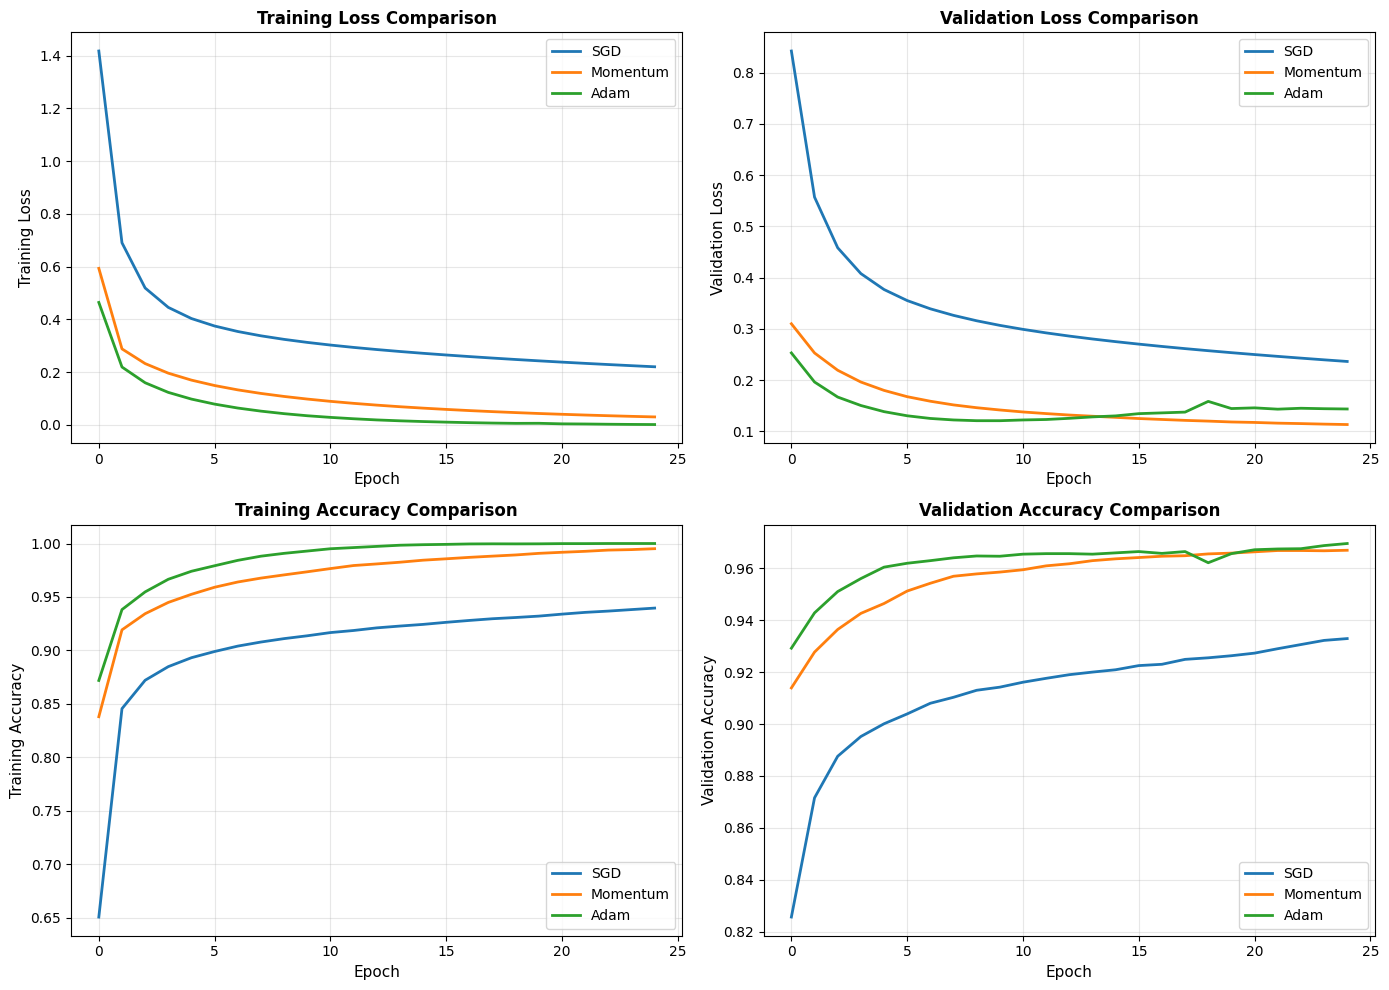

✅ Figure saved as 'optimizer_comparison.png'


In [13]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
ax = axes[0, 0]
for name, res in results.items():
    history = res['history']
    ax.plot(history.history['loss'], label=name, linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss', fontsize=11)
ax.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[0, 1]
for name, res in results.items():
    history = res['history']
    ax.plot(history.history['val_loss'], label=name, linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss', fontsize=11)
ax.set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Training Accuracy
ax = axes[1, 0]
for name, res in results.items():
    history = res['history']
    ax.plot(history.history['accuracy'], label=name, linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Accuracy', fontsize=11)
ax.set_title('Training Accuracy Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1, 1]
for name, res in results.items():
    history = res['history']
    ax.plot(history.history['val_accuracy'], label=name, linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure saved as 'optimizer_comparison.png'")

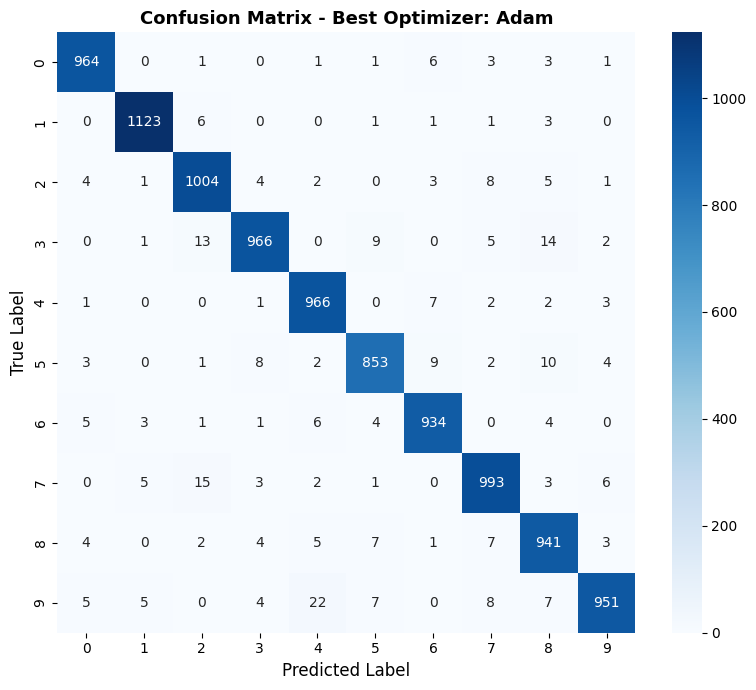


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.96      0.98      0.97       982
           5       0.97      0.96      0.96       892
           6       0.97      0.97      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [14]:
# Confusion matrix for best model
from sklearn.metrics import confusion_matrix, classification_report

best_name = max(results.keys(), key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']

# Get predictions
y_pred_probs = best_model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Best Optimizer: {best_name}', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

---
## Part 7: Critical Analysis

### 📊 Discussion Questions

**1. Convergence Speed**
- **Which optimizer converged fastest to high accuracy?**

Adam 

- **How do the loss curves differ between SGD, Momentum, and Adam?** 

The loss curves reveal a clear hierarchy in convergence speed and shape. SGD traces a gradual, almost linear descent, reflecting a slow and steady approach to the minimum. Momentum improves upon this with a steeper, smoother curve that accelerates over time.  Most notably, Adam exhibits a dramatic "L-shaped" trajectory, plummeting to near-zero loss almost immediately in the early epochs before flattening out

- **Why does Adam typically converge faster?**

Adam typically converges faster because it uses adaptive learning rates, which adjust the step size for every individual weight based on past gradients, combined with momentum to accelerate through flat regions of the loss landscape.

**2. Final Performance**
- **Do all optimizers reach similar final test accuracy?**

No, they do not reach the same accuracy: Adam (97.06%) and Momentum (96.76%) significantly outperformed SGD (93.27%), which suggests that basic SGD can get trapped in plateaus or local minima that more advanced optimizers can easily navigate.

- **Is there a trade-off between convergence speed and final performance?**

In this specific lab, there was no trade-off because the fastest optimizer (Adam) also achieved the highest final accuracy (97.06%), whereas the slowest (SGD) performed the worst. However, in larger models, a trade-off can exist where fast optimizers like Adam converge quickly but may get stuck in "sharp" minima, while slower methods like SGD can eventually find "flatter" minima that generalize better to new data.

- **What does this tell us about the optimization landscape of this problem**

The results suggest that the MNIST optimization landscape contains long, flat plateaus or shallow ravines where gradients are very small, causing basic SGD to stall while adaptive algorithms like Adam successfully accelerate through them to find the global minimum.

**3. Stability**
- **Do you observe oscillations in loss/accuracy curves?**

SGD and Momentum show smooth, steady curves, while Adam exhibits minor oscillations in validation accuracy toward the end of training. This happens because Adam's adaptive steps can become erratic as it reaches the "bottom" of the loss landscape, causing it to bounce slightly around the minimum.

- **How does Momentum affect stability compared to vanilla SGD?**

Momentum significantly improves stability compared to vanilla SGD by dampening the high-frequency oscillations that often occur when the gradient changes direction rapidly. By accumulating a moving average of past gradients, Momentum essentially acts as a "filter" that cancels out noisy, conflicting updates and accelerates the model in a consistent direction toward the minimum.

- **Which optimizer shows the smoothest convergence?**

Momentum shows the smoothest convergence because it combines the steady progress of SGD with a velocity component that filters out noise. While vanilla SGD is also smooth, it is far too slow; Momentum provides the best balance by accelerating in a consistent direction without the sharp, erratic "jitter" or late-stage oscillations often seen in Adam's adaptive learning rate curves.

**4. Hyperparameter Sensitivity**
- **How sensitive is each optimizer to learning rate?**

**SGD** is highly sensitive and requires precise tuning to avoid stalling or exploding, whereas **Adam** is much more robust because its adaptive mechanism automatically adjusts step sizes, making it effective even with less-than-optimal initial learning rate settings.

- **What would happen if you used lr=0.1 for SGD? lr=0.01 for Adam?**

used lr=0.1 for SGD, the model might converge much faster but risks overshooting the minimum or oscillating wildly; conversely, using lr=0.01 for Adam would likely cause the training to become highly unstable or fail to converge ("explode"), as Adam's adaptive mechanism already amplifies updates, making such a high learning rate far too aggressive.

- **Why does Adam typically use smaller learning rates?**

Adam uses smaller learning rates because its formula divides the updates by the square root of the gradient variance; if gradients are small, this division significantly amplifies the effective step size, requiring a smaller base learning rate (like 0.001) to prevent the model from becoming unstable or diverging.

**5. Overfitting**
- **Is there a gap between training and validation accuracy?**

the gap is minimal because the model is simple and MNIST is a highly consistent dataset, meaning the training and validation performance tracked closely together.

- **Which optimizer shows the largest gap?**

Adam typically shows the largest gap because its rapid convergence and adaptive nature allow it to minimize training loss so aggressively that it begins to "memorize" specific noise in the training set rather than just the general patterns.

- **How would you reduce overfitting?**

To reduce overfitting, we should implement Dropout, which randomly deactivates neurons during training to prevent co-dependency, or L2 Regularization (Weight Decay), which penalizes large weights to keep the model mapping simple

**6. Real-World Implications**
- **When would you choose SGD over Adam in production?**

when we prioritize superior generalization and memory efficiency over the rapid convergence and ease of tuning offered by Adam.

- **What are the memory requirements of each optimizer?**

Adam requires $2 \times N$ extra parameters to store its first and second moments, whereas Momentum requires only $1 \times N$ and Vanilla SGD requires zero extra memory, making SGD the most memory-efficient choice for training large-scale models.

- **How do these findings generalize to deeper networks?**

in deeper networks, Adam and Momentum become essential to overcome the vanishing gradient problem and navigate complex saddle points, though the generalization gap often leads researchers back to tuned SGD for reaching peak final accuracy.

### 🔑 Key Observations

**Adam:**
- ✅ Fastest convergence due to adaptive learning rates
- ✅ Less sensitive to learning rate choice
- ✅ Best for rapid prototyping
- ⚠️ Higher memory usage (maintains momentum and variance estimates)
- ⚠️ May generalize slightly worse than SGD in some cases

**Momentum:**
- ✅ Good balance between speed and stability
- ✅ Accelerates convergence in consistent directions
- ✅ Reduces oscillations compared to vanilla SGD
- ⚠️ Adds one hyperparameter (momentum coefficient β)

**SGD:**
- ✅ Most stable and predictable
- ✅ Minimal memory overhead
- ✅ Often achieves best generalization in production
- ⚠️ Slowest convergence
- ⚠️ Very sensitive to learning rate

### 📚 Connection to Next Week

In **Reinforcement Learning**, these optimizers will be used for:
- Training policy networks (actor)
- Training value networks (critic)
- Updating Q-functions

Key difference: In RL, the optimization landscape is **non-stationary** because:
- The data distribution changes as the policy improves
- The targets (rewards) depend on the current policy
- This makes optimization much more challenging!

---
## Part 8: Advanced Extensions (Optional)

### 🚀 Challenge Problems for Strong Students

Try implementing one or more of these extensions:

#### 1. Learning Rate Schedules

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9085 - loss: 0.3016 - val_accuracy: 0.9462 - val_loss: 0.1778
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9554 - loss: 0.1432 - val_accuracy: 0.9541 - val_loss: 0.1525
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9628 - loss: 0.1178 - val_accuracy: 0.9561 - val_loss: 0.1613
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9724 - loss: 0.0841 - val_accuracy: 0.9535 - val_loss: 0.2103
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9774 - loss: 0.0730 - val_accuracy: 0.9501 - val_loss: 0.2198
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9816 - loss: 0.0604 - val_accuracy: 0.9582 - val_loss: 0.2182
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9816 - loss: 0.0559 - val_accuracy: 0.9545 - val_loss: 0.2469
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.

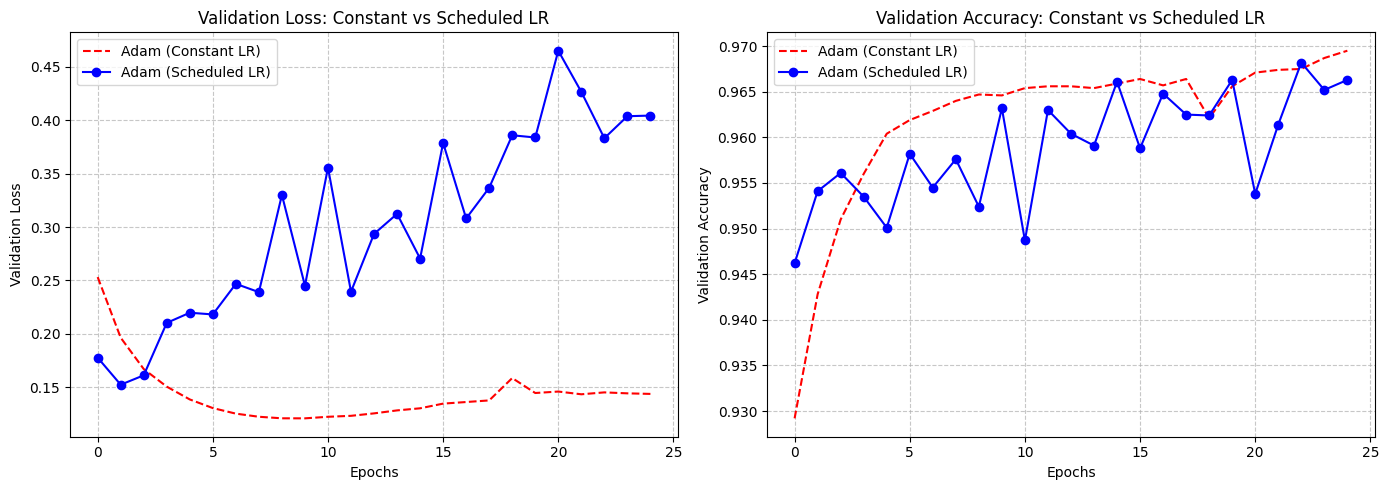

In [15]:
# Example: Exponential decay learning rate
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

# TODO: Train with scheduled learning rate and compare with constant LR
model_scheduled = build_mlp_model()
optimizer_scheduled = optimizers.Adam(learning_rate=lr_schedule)
model_scheduled.compile(optimizer=optimizer_scheduled, 
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy'])

history_scheduled = model_scheduled.fit(x_train_flat, y_train, 
                                        epochs=EPOCHS, # Match this to the epochs you used earlier!
                                        batch_size=64, 
                                        validation_data=(x_test_flat, y_test), 
                                        verbose=1)


plt.figure(figsize=(14, 5))

# Plot Validation Loss
plt.subplot(1, 2, 1)
plt.plot(hist_adam.history['val_loss'], label='Adam (Constant LR)', linestyle='--', color='red')
plt.plot(history_scheduled.history['val_loss'], label='Adam (Scheduled LR)', marker='o', color='blue')
plt.title('Validation Loss: Constant vs Scheduled LR')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist_adam.history['val_accuracy'], label='Adam (Constant LR)', linestyle='--', color='red')
plt.plot(history_scheduled.history['val_accuracy'], label='Adam (Scheduled LR)', marker='o', color='blue')
plt.title('Validation Accuracy: Constant vs Scheduled LR')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6578 - loss: 1.4311 - val_accuracy: 0.8288 - val_loss: 0.8494
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8425 - loss: 0.6925 - val_accuracy: 0.8682 - val_loss: 0.5614
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8705 - loss: 0.5219 - val_accuracy: 0.8822 - val_loss: 0.4627
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8841 - loss: 0.4493 - val_accuracy: 0.8898 - val_loss: 0.4134
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8924 - loss: 0.4082 - val_accuracy: 0.8964 - val_loss: 0.3826
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8982 - loss: 0.3805 - val_accuracy: 0.9004 - val_loss: 0.3612
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9024 - loss: 0.3601 - val_accuracy: 0.9032 - val_loss: 0.3455
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9064 - loss: 0.3443 - val_accuracy: 0.

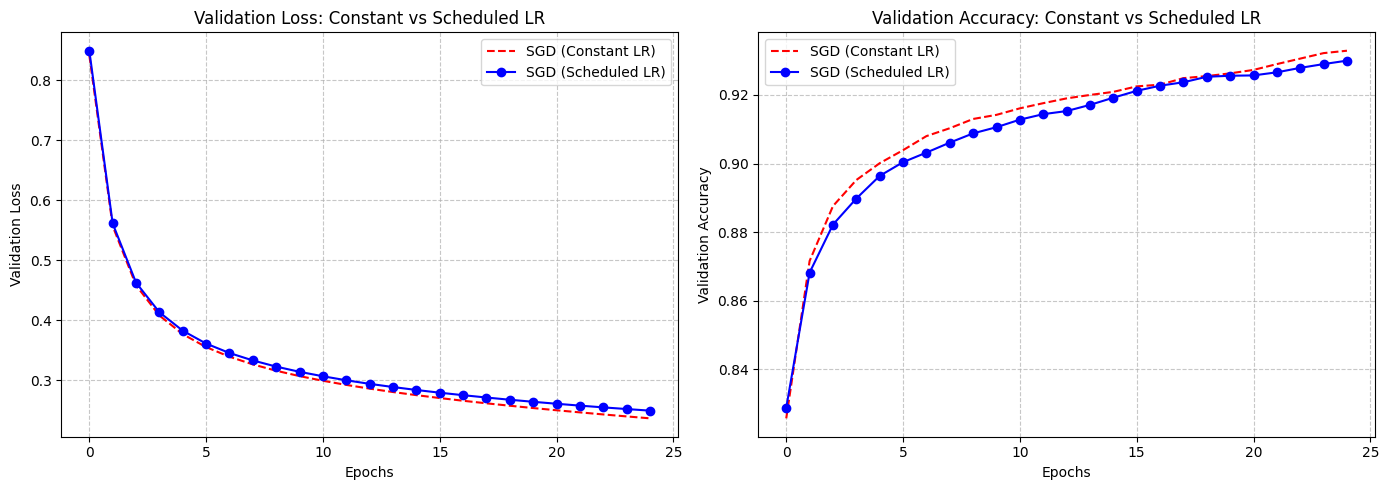

In [20]:
model_scheduled_SGD = build_mlp_model()
optimizer_scheduled = optimizers.SGD(learning_rate=lr_schedule)
model_scheduled_SGD.compile(optimizer=optimizer_scheduled, 
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy'])

history_scheduled = model_scheduled_SGD.fit(x_train_flat, y_train, 
                                        epochs=EPOCHS, # Match this to the epochs you used earlier!
                                        batch_size=64, 
                                        validation_data=(x_test_flat, y_test), 
                                        verbose=1)


plt.figure(figsize=(14, 5))

# Plot Validation Loss
plt.subplot(1, 2, 1)
plt.plot(hist_sgd.history['val_loss'], label='SGD (Constant LR)', linestyle='--', color='red')
plt.plot(history_scheduled.history['val_loss'], label='SGD (Scheduled LR)', marker='o', color='blue')
plt.title('Validation Loss: Constant vs Scheduled LR')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist_sgd.history['val_accuracy'], label='SGD (Constant LR)', linestyle='--', color='red')
plt.plot(history_scheduled.history['val_accuracy'], label='SGD (Scheduled LR)', marker='o', color='blue')
plt.title('Validation Accuracy: Constant vs Scheduled LR')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### 2. Regularization Techniques

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8364 - loss: 0.7041 - val_accuracy: 0.9251 - val_loss: 0.3950
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9190 - loss: 0.4061 - val_accuracy: 0.9417 - val_loss: 0.3186
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9347 - loss: 0.3369 - val_accuracy: 0.9474 - val_loss: 0.2823
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9421 - loss: 0.3051 - val_accuracy: 0.9516 - val_loss: 0.2622
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9464 - loss: 0.2805 - val_accuracy: 0.9555 - val_loss: 0.2453
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9501 - loss: 0.2625 - val_accuracy: 0.9582 - val_loss: 0.2336
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9546 - loss: 0.2446 - val_accuracy: 0.9606 - val_loss: 0.2202
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9567 - loss: 0.2349 - val_accuracy: 0

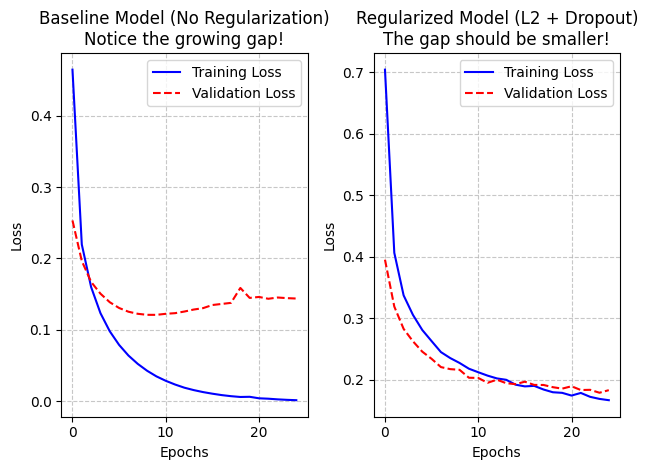

In [16]:
# Example: Add dropout and L2 regularization
def build_mlp_with_regularization():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    return model

# TODO: Train with regularization and measure impact on overfitting
model_reg = build_mlp_with_regularization()
model_reg.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy'])
history_reg = model_reg.fit(x_train_flat, y_train, 
                                epochs=EPOCHS, 
                                batch_size=64, 
                                validation_data=(x_test_flat, y_test), 
                                verbose=1)

# --- Plot 1: Baseline Model (No Regularization) ---
plt.subplot(1, 2, 1)
plt.plot(hist_adam.history['loss'], label='Training Loss', color='blue')
plt.plot(hist_adam.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Baseline Model (No Regularization)\nNotice the growing gap!')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Regularized Model ---
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['loss'], label='Training Loss', color='blue')
plt.plot(history_reg.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Regularized Model (L2 + Dropout)\nThe gap should be smaller!')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 3. Batch Size Analysis

Training with Batch Size: 16...
 Done in 158.30s | Final Val Acc: 0.9731
Training with Batch Size: 32...
 Done in 85.38s | Final Val Acc: 0.9682
Training with Batch Size: 64...
 Done in 47.71s | Final Val Acc: 0.9702
Training with Batch Size: 128...
 Done in 31.83s | Final Val Acc: 0.9683
Training with Batch Size: 256...
 Done in 19.61s | Final Val Acc: 0.9645


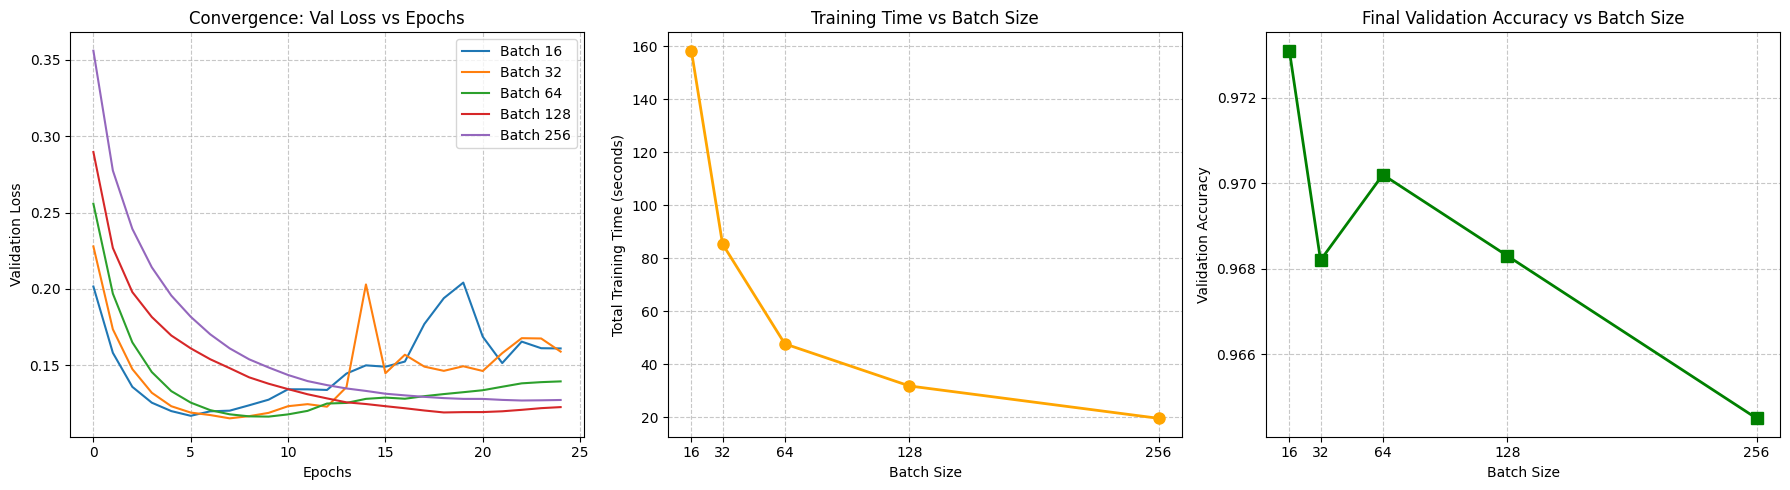

In [17]:
# TODO: Try different batch sizes: [16, 32, 64, 128, 256]
# Plot: convergence speed vs batch size
# Analyze: training time vs final accuracy

import time

batch_sizes = [16, 32, 64, 128, 256]


# Dictionaries/lists to store our results
histories_batch = {}
training_times = []
final_accuracies = []

for bs in batch_sizes:
    print(f"Training with Batch Size: {bs}...")
    
    # 1. Build a fresh model for each batch size so we start from scratch
    model_bs = build_mlp_model() 
    model_bs.compile(optimizer='adam', 
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy'])
    
    # 2. Record the start time
    start_time = time.time()
    
    # 3. Train the model (verbose=0 to avoid huge walls of text)
    history = model_bs.fit(x_train_flat, y_train, 
                            epochs=EPOCHS, 
                            batch_size=bs,
                            validation_data=(x_test_flat, y_test), 
                            verbose=0)
                        
    # 4. Record the end time and metrics
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    histories_batch[bs] = history
    training_times.append(elapsed_time)
    
    # Grab the validation accuracy from the very last epoch
    final_acc = history.history['val_accuracy'][-1]
    final_accuracies.append(final_acc)
    
    print(f" Done in {elapsed_time:.2f}s | Final Val Acc: {final_acc:.4f}")

# ==========================================
# PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(18, 5))

# Plot 1: Convergence Speed (Validation Loss over Epochs)
plt.subplot(1, 3, 1)
for bs in batch_sizes:
    plt.plot(histories_batch[bs].history['val_loss'], label=f'Batch {bs}')
plt.title('Convergence: Val Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training Time vs Batch Size
plt.subplot(1, 3, 2)
plt.plot(batch_sizes, training_times, marker='o', color='orange', linewidth=2, markersize=8)
plt.title('Training Time vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Total Training Time (seconds)')
plt.xticks(batch_sizes) # Force x-axis to only show our specific batch sizes
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 3: Final Accuracy vs Batch Size
plt.subplot(1, 3, 3)
plt.plot(batch_sizes, final_accuracies, marker='s', color='green', linewidth=2, markersize=8)
plt.title('Final Validation Accuracy vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.xticks(batch_sizes)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4. Deeper Architectures

In [18]:
# TODO: Build 3-4 layer MLPs
# Compare optimization difficulty vs shallow network

def build_deep_mlp():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

Training Shallow Network...
Training Deep Network (3 hidden layers)...
Training complete! Plotting results...


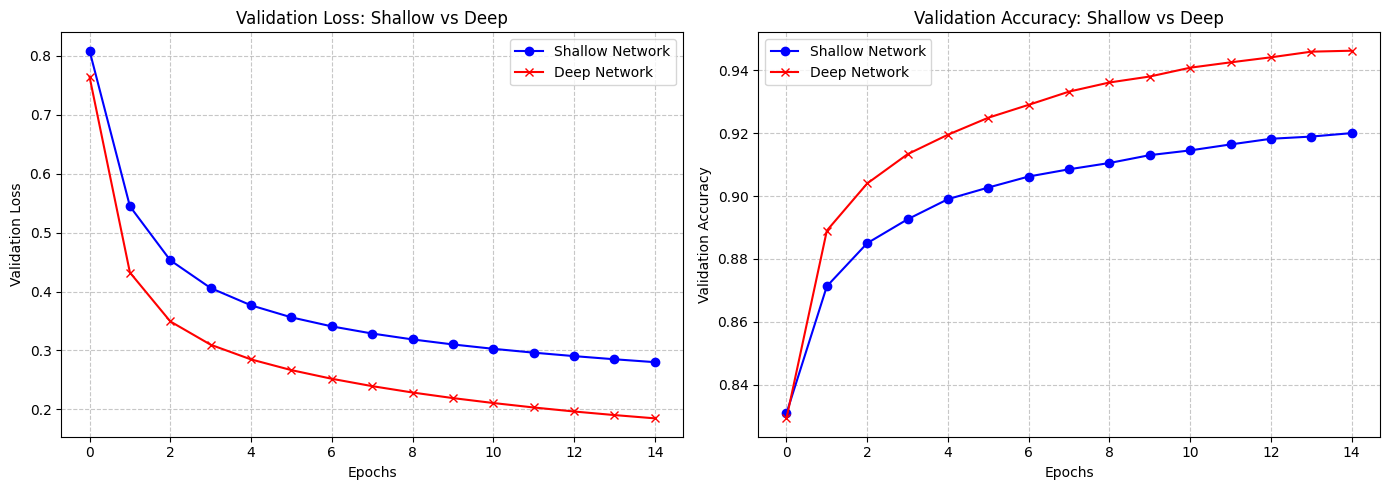

In [21]:
model_shallow = build_mlp_model() 
model_deep = build_deep_mlp()

# 2. Compile both models
# We use standard SGD to highlight how deep networks struggle with basic optimizers
model_shallow.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), 
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy'])

model_deep.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), 
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy'])

epochs = 15
batch_size = 64

# 3. Train both models
print("Training Shallow Network...")
history_shallow = model_shallow.fit(x_train_flat, y_train, 
                                    epochs=epochs, 
                                    batch_size=batch_size, 
                                    validation_data=(x_test_flat, y_test), 
                                    verbose=0) # Change to 1 if you want to watch the progress

print("Training Deep Network (3 hidden layers)...")
history_deep = model_deep.fit(x_train_flat, y_train, 
                                epochs=epochs, 
                                batch_size=batch_size, 
                                validation_data=(x_test_flat, y_test), 
                                verbose=0)

print("Training complete! Plotting results...")

# ==========================================
# PLOTTING THE COMPARISON
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history_shallow.history['val_loss'], label='Shallow Network', marker='o', color='blue')
plt.plot(history_deep.history['val_loss'], label='Deep Network', marker='x', color='red')
plt.title('Validation Loss: Shallow vs Deep')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_shallow.history['val_accuracy'], label='Shallow Network', marker='o', color='blue')
plt.plot(history_deep.history['val_accuracy'], label='Deep Network', marker='x', color='red')
plt.title('Validation Accuracy: Shallow vs Deep')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 5. Custom Callbacks

In [25]:
# Example: Early stopping and model checkpointing
import os


early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

# TODO: Train with callbacks and analyze their impact

model_callbacks = build_mlp_model()
model_callbacks.compile(optimizer='adam', 
                        loss='sparse_categorical_crossentropy', 
                        metrics=['accuracy'])

# Train with Callbacks
print("Training with Early Stopping & Checkpointing (Max 50 epochs)...")
history_callbacks = model_callbacks.fit(x_train_flat, y_train, 
                                        epochs=50, # Intentionally high
                                        batch_size=64,
                                        validation_data=(x_test_flat, y_test),
                                        callbacks=[early_stop, checkpoint], # Pass callbacks here
                                        verbose=1)

print(f"Training stopped after {len(history_callbacks.history['loss'])} epochs.")

# 4. Verify the saved model
if os.path.exists('best_model.h5'):
    file_size = os.path.getsize('best_model.h5') / (1024 * 1024)
    print(f"Best model successfully saved to disk! Size: {file_size:.2f} MB")

Training with Early Stopping & Checkpointing (Max 50 epochs)...
Epoch 1/50
304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7781 - loss: 0.7953

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8725 - loss: 0.4664 - val_accuracy: 0.9293 - val_loss: 0.2516
Epoch 2/50
301/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9320 - loss: 0.2420

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9395 - loss: 0.2186 - val_accuracy: 0.9422 - val_loss: 0.1956
Epoch 3/50
303/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9502 - loss: 0.1733

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9557 - loss: 0.1593 - val_accuracy: 0.9515 - val_loss: 0.1663
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9638 - loss: 0.1322

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9669 - loss: 0.1230 - val_accuracy: 0.9562 - val_loss: 0.1483
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9708 - loss: 0.1046

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9803 - loss: 0.0783 - val_accuracy: 0.9611 - val_loss: 0.1288
Epoch 7/50
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9830 - loss: 0.0676

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9844 - loss: 0.0634 - val_accuracy: 0.9626 - val_loss: 0.1241
Epoch 8/50
302/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9870 - loss: 0.0549

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9882 - loss: 0.0514 - val_accuracy: 0.9641 - val_loss: 0.1215
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9916 - loss: 0.0415 - val_accuracy: 0.9640 - val_loss: 0.1198
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9934 - loss: 0.0336 - val_accuracy: 0.9634 - val_loss: 0.1202
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9955 - loss: 0.0273 - val_accuracy: 0.9638 - val_loss: 0.1218
Epoch 12/50
304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9960 - loss: 0.0238

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9967 - loss: 0.0220 - val_accuracy: 0.9645 - val_loss: 0.1228
Epoch 13/50
304/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9973 - loss: 0.0191

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9977 - loss: 0.0177 - val_accuracy: 0.9651 - val_loss: 0.1248
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9983 - loss: 0.0143 - val_accuracy: 0.9650 - val_loss: 0.1278
Training stopped after 14 epochs.
Best model successfully saved to disk! Size: 1.19 MB


---
## Summary & Next Steps

### ✅ What You Accomplished Today

1. ✅ Loaded and preprocessed MNIST dataset
2. ✅ Built a simple MLP classifier with TensorFlow/Keras
3. ✅ Compared three optimization algorithms: SGD, Momentum, Adam
4. ✅ Analyzed convergence behavior and final performance
5. ✅ Visualized training dynamics and confusion matrix
6. ✅ Understood trade-offs between different optimizers

### 🎯 Key Takeaways

- **Optimization matters:** Choice of optimizer significantly impacts training speed
- **No universal best:** Each optimizer has strengths and weaknesses
- **Understanding fundamentals:** Knowing how optimizers work helps debug issues
- **TensorFlow/Keras:** High-level API makes experimentation easy

### 📚 Preparation for Week 2: Reinforcement Learning

**Topics:**
- Markov Decision Processes (MDPs)
- Value functions and Bellman equations
- Q-Learning algorithm
- Exploration vs Exploitation

**Required Reading:**
- Sutton & Barto, Chapters 3-4
- Review Markov chains and dynamic programming

**Install:**
```bash
pip install gymnasium pygame
```

### 🚀 See You Next Week!

---
**End of Week 1 Lab**